In [3]:
import sys
sys.path.append('..')  # so `src` is importable from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_and_validate, get_class_distribution

# Using the validated loader (not a raw pd.read_csv) so any schema
# issue surfaces here, at cell 1, rather than mid-analysis.
df = load_and_validate()
df.shape

(284807, 31)

In [4]:
dist = get_class_distribution(df)
print(dist)

fraud_count = df['Class'].sum()
total = len(df)
print(f"\nFraud cases: {fraud_count} / {total} ({fraud_count/total:.4%})")

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

Fraud cases: 492 / 284807 (0.1727%)


/var/folders/05/6xfvtbr91rv8mcsm5sxsxv840000gn/T/ipykernel_41198/967052375.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])


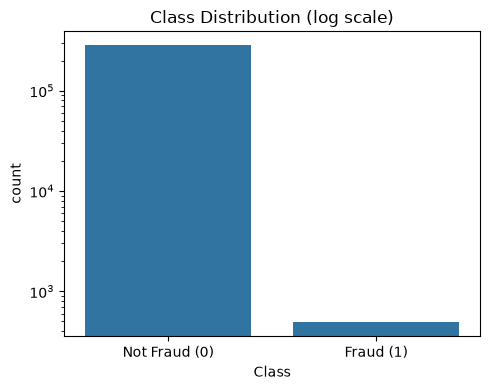

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x='Class', ax=ax)
ax.set_yscale('log')  # log scale is necessary here — on a linear
                       # scale the fraud bar is visually invisible
ax.set_title('Class Distribution (log scale)')
ax.set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

/var/folders/05/6xfvtbr91rv8mcsm5sxsxv840000gn/T/ipykernel_41198/3557169591.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(['Not Fraud', 'Fraud'])


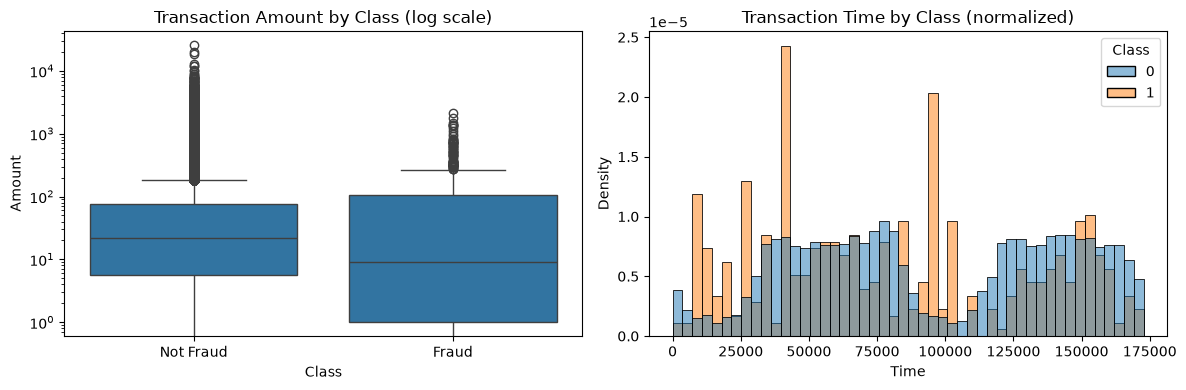

In [ ]:
# Boxplot of transaction amount by class, and histogram of transaction time by class
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x='Class', y='Amount', ax=axes[0])
axes[0].set_yscale('log')  # Amount is heavily right-skewed;
                             # log scale keeps outliers visible
axes[0].set_title('Transaction Amount by Class (log scale)')
axes[0].set_xticklabels(['Not Fraud', 'Fraud'])

sns.histplot(data=df, x='Time', hue='Class', bins=48, common_norm=False,
             stat='density', ax=axes[1])
axes[1].set_title('Transaction Time by Class (normalized)')

plt.tight_layout()
plt.show()

In [7]:
print("Amount summary by class:")
df.groupby('Class')['Amount'].describe()

Amount summary by class:


,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87
